In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

In [25]:
class BB_Base():

    def __init__(self, start, end, amount):
        self.symbol = "BTC-USD"
        self.start = start
        self.end = end
        self.initial_balance = amount
        self.current_balance = amount
        self.units = 0 
        self.get_data()

    def get_data(self):
        raw = pd.read_csv("btcusdt_1h.csv", parse_dates = ["datetime"], index_col = "datetime").dropna()
        raw.drop(columns=["open","high","low"], inplace = True)
        raw = raw.loc[self.start:self.end]
        raw["buy_n_hold_returns"] = np.log(raw.close / raw.close.shift(1))
        self.data = raw

    def plot_data(self, cols = None):  
        if cols is None:
            cols = ["close","SMA","Lower","Upper"]
        #change colors to blue for upper bollinger band, red for lower bollinger band
        #black for SMA, green for close price
        self.data[cols].plot(figsize=(12, 8), color=["blue","red","black","green"], title="Bollinger Bands")
    
    def get_values(self, bar):
        date = str(self.data.index[bar].date())
        price = round(self.data.close.iloc[bar], 5)
        return date, price
    
    def print_current_balance(self, bar):
        date, price = self.get_values(bar)
        print("{} | Current Balance: {}".format(date, round(self.current_balance, 2)))
        
    def buy_instrument(self, bar, units = None, amount = None):
        date, price = self.get_values(bar)
        if amount is not None: 
            units = int(amount / price)
        self.current_balance -= units * price 
        self.units += units
    
    def sell_instrument(self, bar, units = None, amount = None):
        date, price = self.get_values(bar)
        if amount is not None: 
            units = int(amount / price)
        self.current_balance += units * price
        self.units -= units
        
    def close_pos(self, bar):
        date, price = self.get_values(bar)
        self.current_balance += self.units * price
        self.units = 0
        perf = (self.current_balance - self.initial_balance) / self.initial_balance * 100
        self.print_current_balance(bar)
        print("{} | net performance (%) = {}".format(date, round(perf, 2) ))
        
    def plot_results(self):
        if self.results is None:
            print("Run test_strategy() first.")
        else:
            title = "{} | Bollinger Bands with standard deviation of +-2 away from SMA. ".format(self.symbol)
            self.results[["creturns", "cstrategy_returns","max_strategy_returns"]].plot(title=title, figsize=(12, 8))
        
    
        
class BB_Action(BB_Base):

    def go_long(self, bar, units = None, amount = None):
        if self.position == -1:
            self.buy_instrument(bar, units = -self.units) # if short position, go neutral first
        if units:
            self.buy_instrument(bar, units = units)
        elif amount:
            if amount == "all":
                amount = self.current_balance
            self.buy_instrument(bar, amount = amount) # go long
            
    def go_short(self, bar, units = None, amount = None):
        if self.position == 1:
            self.sell_instrument(bar, units = self.units) # if long position, go neutral first
        if units:
            self.sell_instrument(bar, units = units)
        elif amount:
            if amount == "all":
                amount = self.current_balance
            self.sell_instrument(bar, amount = amount) # go short

    def test_bb_strategy(self, SMA, dev):
         
        self.position = 0  # initial neutral position
        self.current_balance = self.initial_balance  # reset initial capital
        self.get_data() # reset dataset
        
        # prepare data
        self.data["SMA"] = self.data["close"].rolling(SMA).mean()
        self.data["Lower"] = self.data["SMA"] - self.data["close"].rolling(SMA).std() * dev
        self.data["Upper"] = self.data["SMA"] + self.data["close"].rolling(SMA).std() * dev
        self.data.dropna(inplace = True) 
        
        # Bollinger strategy
        for bar in range(len(self.data)-1): # all bars (except the last bar)
            if self.position == 0: # when neutral
                if self.data["close"].iloc[bar] < self.data["Lower"].iloc[bar]: # signal to go long
                    self.go_long(bar, amount = "all") # go long with full amount
                    self.position = 1  # long position
                    self.data.at[self.data.index[bar],"position"] = 1
                elif self.data["close"].iloc[bar] > self.data["Upper"].iloc[bar]: # signal to go Short
                    self.go_short(bar, amount = "all") # go short with full amount
                    self.position = -1 # short position
                    self.data.at[self.data.index[bar],"position"] = -1
                else:
                    self.data.at[self.data.index[bar],"position"] = 0
            elif self.position == 1: # when long
                if self.data["close"].iloc[bar] > self.data["SMA"].iloc[bar]:
                    if self.data["close"].iloc[bar] > self.data["Upper"].iloc[bar]: # signal to go short
                        self.go_short(bar, amount = "all") # go short with full amount
                        self.position = -1 # short position
                        self.data.at[self.data.index[bar],"position"] = -1
                    else:
                        self.sell_instrument(bar, units = self.units) # go neutral
                        self.position = 0
                        self.data.at[self.data.index[bar],"position"] = 0
                else:
                    self.data.at[self.data.index[bar],"position"] = 1
            elif self.position == -1: # when short
                if self.data["close"].iloc[bar] < self.data["SMA"].iloc[bar]:
                    if self.data["close"].iloc[bar] < self.data["Lower"].iloc[bar]: # signal to go long
                        self.go_long(bar, amount = "all") # go long with full amount
                        self.position = 1 # long position
                        self.data.at[self.data.index[bar],"position"] = 1
                    else:
                        self.buy_instrument(bar, units = -self.units) # go neutral
                        self.position = 0  
                        self.data.at[self.data.index[bar],"position"] = 0
                else:
                    self.data.at[self.data.index[bar],"position"] = -1
        self.close_pos(bar+1) # close position at the last bar
        
        data = self.data.copy().dropna()
        data["strategy_returns"] = data["position"].shift(1) * data["buy_n_hold_returns"]
        data.dropna(inplace=True)
        data["creturns"] = data["buy_n_hold_returns"].cumsum().apply(np.exp)
        data["cstrategy_returns"] = data["strategy_returns"].cumsum().apply(np.exp)
        data["max_strategy_returns"] = data["cstrategy_returns"].cummax()
        self.results = data

In [26]:
tester = BB_Action("2018-01-01", "2022-12-31", 100000)

In [27]:
tester.data

,close,volume,buy_n_hold_returns
datetime,,,
2018-01-01 05:30:00,13529.01,443.356199,NaN
2018-01-01 06:30:00,13203.06,383.697006,-0.024388
2018-01-01 07:30:00,13330.18,429.064572,0.009582
2018-01-01 08:30:00,13410.03,420.087030,0.005972
2018-01-01 09:30:00,13601.01,340.807329,0.014141
...,...,...,...
2022-01-12 01:30:00,42800.38,1219.601780,-0.004003
2022-01-12 02:30:00,42659.20,702.103800,-0.003304
2022-01-12 03:30:00,42713.13,561.859930,0.001263


In [28]:
tester.test_bb_strategy(20,3)

2022-01-12 | Current Balance: 30295.88
2022-01-12 | net performance (%) = -69.7


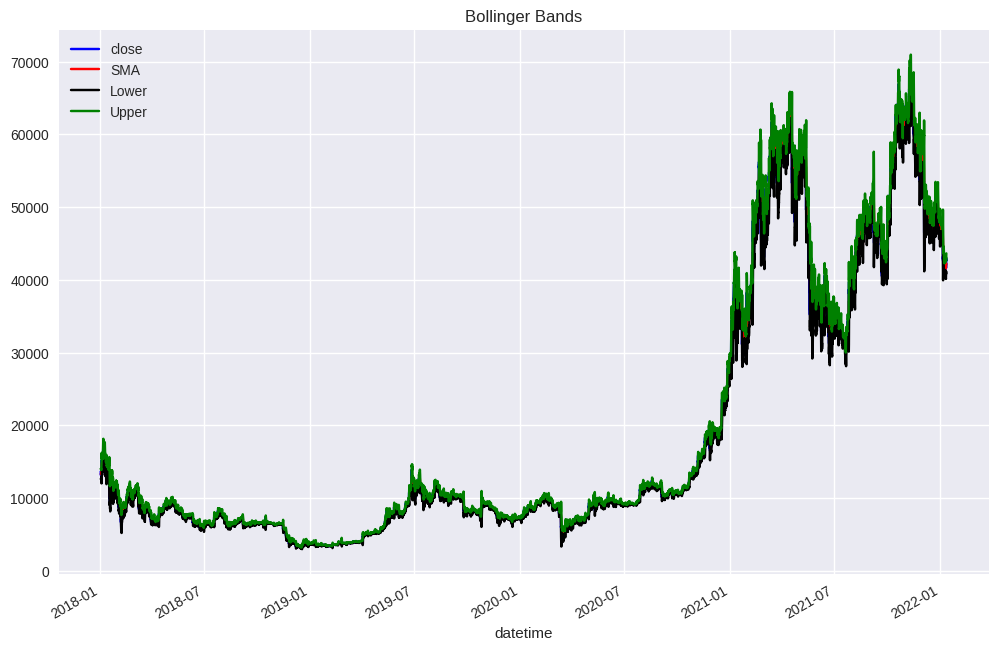

In [29]:
tester.plot_data()

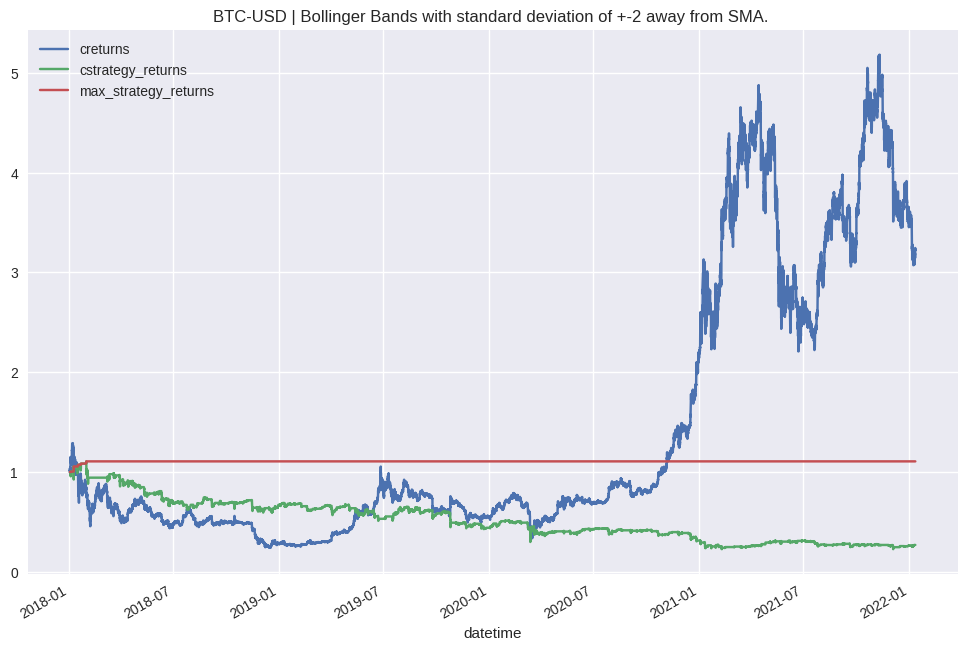

In [30]:
tester.plot_results()

In [31]:
tester.results

,close,volume,buy_n_hold_returns,SMA,Lower,Upper,position,strategy_returns,creturns,cstrategy_returns,max_strategy_returns
datetime,,,,,,,,,,,
2018-01-02 01:30:00,13399.24,412.026868,0.011927,13341.2000,12661.892619,14020.507381,0.0,0.0,1.011999,1.000000,1.000000
2018-01-02 02:30:00,13481.01,326.923135,0.006084,13355.0975,12676.976096,14033.218904,0.0,0.0,1.018175,1.000000,1.000000
2018-01-02 03:30:00,13452.00,303.301385,-0.002154,13361.1885,12680.269268,14042.107732,0.0,-0.0,1.015984,1.000000,1.000000
2018-01-02 04:30:00,13380.00,345.218495,-0.005367,13359.6870,12679.490488,14039.883512,0.0,-0.0,1.010546,1.000000,1.000000
2018-01-02 05:30:00,13750.01,466.596114,0.027278,13367.1370,12655.292640,14078.981360,0.0,0.0,1.038491,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...
2022-01-12 00:30:00,42972.05,1440.445690,0.005064,42099.7000,40897.992994,43301.407006,0.0,0.0,3.245532,0.268855,1.106542
2022-01-12 01:30:00,42800.38,1219.601780,-0.004003,42160.0340,40926.790341,43393.277659,0.0,-0.0,3.232567,0.268855,1.106542
2022-01-12 02:30:00,42659.20,702.103800,-0.003304,42196.5530,40931.263043,43461.842957,0.0,-0.0,3.221904,0.268855,1.106542
